# Where does physics help a graph network? — every finding, reproduced

District-level weekly dengue forecasting for Sri Lanka (25 districts, 3-week window →
3-week horizon). This notebook reproduces **every result in the full paper** and the
experiment log behind it (EXP-032 … EXP-049), in the order of the paper:

| § | finding | source rows |
|---|---|---|
| 1 | the corrected data, and the persistence floor recomputed from it | `data/` |
| 2 | the benchmark array's audit: why we do not use the original shifted dataset | `array_audit.json` |
| 3 | six encoders × three heads on one harness | `real.json` |
| 4 | why the pure SEIR decoder fails | EXP-032 (diagnosis) |
| 5 | anchor, gate or physics? the rescue control | `rescue.json` |
| 6 | every lever we tried, paired against its own control | 9 grids |
| 7 | the best model against persistence, on validation and test | `combo.json`, `confirm.json`, `physics9.json` |
| 8 | SEIR-GNN against SEIR-LSTM, three and nine origins | `combo`, `physics`, `confirm`, `physics9` |
| 9 | physics as structure: spatial penalty, metapopulation head | `physics.json` |
| 10 | the informational ceiling | `diagnose_arch.txt` + levers |
| 11 | validation and test disagree | every grid |
| 12 | what happened to the earlier "positive physics" results | EXP-049 kernels |
| 13 | summary of findings | computed above |
| 14 | re-running any of it | `RERUN = True` |

## How to read the numbers

* **RMSE in weekly cases**, lower is better. **Validation decides; test is only
  reported** (plan R6). A difference that only appears on test is not a result.
* **Paired tests.** Arms are compared on matched `(origin, seed)` runs with an exact
  two-sided sign-flip permutation test, Benjamini–Hochberg corrected within a family.
  With **three origins** the *origin* unit cannot reach p < 0.25, so three-origin
  p-values (at the `origin_seed` unit, n = 9) describe run-to-run stability, not the
  series. Claims about the series need the **nine-origin** grids (`confirm`,
  `physics9`), where the origin unit reaches 0.004.
* **Never compare across grids or origin sets.** Each grid carries its own
  persistence row for exactly its own test windows.

**Requires** numpy, pandas, matplotlib. Runs in under a minute with `RERUN = False`.

In [1]:
RERUN = False          # True: retrain the grids in RERUN_GRIDS with seirgnn2 (repo only, hours)
RERUN_GRIDS = []       # e.g. ["rescue"]; see section 14

import itertools, json, re, subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

HERE = next(p for p in (Path.cwd(), Path.cwd() / "full_paper", Path.cwd().parent)
            if (p / "outputs" / "results").exists())
RES, DATA, FIGS = HERE / "outputs" / "results", HERE / "data", HERE / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
REPO = HERE.parent if (HERE.parent / "seirgnn2").exists() else None


def load(grid: str) -> pd.DataFrame:
    # Freshly re-run grids (section 14) take precedence over the committed rows.
    fresh = REPO / "seirgnn2" / "results" / f"{grid}.json" if REPO else None
    src = fresh if (RERUN and grid in RERUN_GRIDS and fresh and fresh.exists()) else RES / f"{grid}.json"
    df = pd.DataFrame(json.loads(src.read_text(encoding="utf-8")))
    if "name" not in df:
        df["name"] = np.nan
    df["name"] = df["name"].fillna(df.get("backbone", "") + "+" + df.get("head", ""))
    return df


GRIDS = {g: load(g) for g in ["screen", "real", "combo", "window", "confirm", "remedies+ens",
                              "curve", "augment", "climate", "arch", "physics", "physics9", "rescue"]}
for g, d in GRIDS.items():
    arms = d.name.nunique() - int((d.name == "persistence").any())
    print(f"{g:13s} {len(d):4d} runs  {arms:3d} arms  origins={sorted(d.origin.unique())}")

screen         138 runs   15 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
real           165 runs   18 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
combo          219 runs   24 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
window         117 runs   14 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
confirm        144 runs    5 arms  origins=[np.float64(0.4), np.float64(0.4667), np.float64(0.5333), np.float64(0.6), np.float64(0.6667), np.float64(0.7333), np.float64(0.8), np.float64(0.8667), np.float64(0.9333)]
remedies+ens   120 runs   13 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
curve           39 runs    4 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
augment         84 runs    9 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
climate         75 runs    8 arms  origins=[np.float64(0.55), np.float64(0.7), np.float64(0.85)]
arch     

In [2]:
def cells(df, metric):
    # {arm: {(origin, seed): value}}; persistence is deterministic and stored with seed -1.
    return {arm: g.groupby(["origin", "seed"])[metric].mean().to_dict() for arm, g in df.groupby("name")}


def diffs(df, arm, ref, metric="val_RMSE", unit="origin_seed"):
    # arm - ref on matched units; a seedless reference is broadcast across the arm's seeds.
    c = cells(df, metric)
    a, r = c[arm], c[ref]
    r_by_origin = {}
    for (o, s), v in r.items():
        r_by_origin.setdefault(o, []).append(v)
    seeded = any(s >= 0 for _, s in r)
    out = {}
    for (o, s), v in sorted(a.items()):
        base = r[(o, s)] if seeded and (o, s) in r else np.mean(r_by_origin[o]) if o in r_by_origin else None
        if base is not None:
            out.setdefault(o, []).append(v - base)
    if unit == "origin":
        return np.array([np.mean(v) for _, v in sorted(out.items())])
    return np.array([x for _, v in sorted(out.items()) for x in v])


def sign_flip_p(d, n_perm=100_000, seed=42):
    # Exact two-sided sign-flip test for n <= 16, Monte Carlo above (as seirgnn2/stats.py).
    d = np.asarray(d, float)
    if len(d) <= 16:
        flips = np.array(list(itertools.product((-1, 1), repeat=len(d))), float)
    else:
        flips = np.random.default_rng(seed).choice((-1.0, 1.0), size=(n_perm, len(d)))
    return float((np.abs(flips @ d / len(d)) >= abs(d.mean()) - 1e-12).mean())


def bh(p):
    p = np.asarray(p, float); m = len(p); adj = np.empty(m); run = 1.0
    for rank, i in reversed(list(enumerate(np.argsort(p), start=1))):
        run = min(run, p[i] * m / rank); adj[i] = min(run, 1.0)
    return adj


def compare(df, arm, ref, metric="val_RMSE", unit="origin_seed"):
    d = diffs(df, arm, ref, metric, unit)
    return {"delta": d.mean(), "wins": f"{int((d < 0).sum())}/{len(d)}", "p": sign_flip_p(d)}


def means(df, names=None):
    t = df.groupby("name").agg(val=("val_RMSE", "mean"), test=("RMSE", "mean"), runs=("name", "size"))
    return t.loc[names] if names else t.sort_values("val")


print("helpers ready: cells, diffs, sign_flip_p, bh, compare, means")

helpers ready: cells, diffs, sign_flip_p, bh, compare, means


## 1. The corrected data, and the persistence floor recomputed from it

The case series was rebuilt from all 552 weekly epidemiological reports, keyed by
report volume and number: **559 weeks, 2013-W26 → 2024-W10**. The seven weeks with no
published report stay **missing** — never interpolated — and any forecast window that
touches one is dropped.

As an independent check on the whole harness, the next cell recomputes the naive
persistence forecast (next three weeks = last observed week) directly from the CSV,
using the same fold rule as `seirgnn2/core.py::build_folds`, and compares it with the
persistence rows stored in the result files.

In [3]:
cases_df = pd.read_csv(DATA / "rebuilt_cases_weekly.csv", parse_dates=["week_start"])
names = [c for c in cases_df.columns if c not in ("week_start", "missing")]
cases = cases_df[names].to_numpy(float)
missing = cases_df["missing"].to_numpy(bool)
print(f"{cases.shape[0]} weeks x {cases.shape[1]} districts, "
      f"{cases_df.week_start.min():%Y-%m-%d} .. {cases_df.week_start.max():%Y-%m-%d}; "
      f"missing weeks: {missing.sum()} (left as NaN)")

WINDOW, H = 3, 3


def folds(origins, test_frac):
    bad = set(np.where(missing)[0]); ids = list(range(WINDOW, len(cases) - H))
    clean = lambda i: not any(t in bad for t in range(i - WINDOW, i + H))
    out = {}
    for o in origins:
        cut, end = int(o * len(ids)), int(min(o + test_frac, 1.0) * len(ids))
        out[o] = {"val": [i for i in ids[cut - 30:cut] if clean(i)],
                  "test": [i for i in ids[cut:end] if clean(i)]}
    return out


def persistence_rmse(idx):
    y = np.stack([cases[i:i + H] for i in idx]); p = np.stack([np.repeat(cases[i - 1][None], H, 0) for i in idx])
    return float(np.sqrt(np.mean((p - y) ** 2)))


check = []
for grid, origins, frac in (("real", (0.55, 0.70, 0.85), 0.15),
                            ("confirm", tuple(round(0.40 + k / 15, 4) for k in range(9)), 1 / 15)):
    f = folds(origins, frac); stored = GRIDS[grid].query("name == 'persistence'").set_index("origin")
    for o in origins:
        check.append({"grid": grid, "origin": o, "test windows": len(f[o]["test"]),
                      "recomputed test": persistence_rmse(f[o]["test"]), "stored test": stored.loc[o, "RMSE"],
                      "recomputed val": persistence_rmse(f[o]["val"]), "stored val": stored.loc[o, "val_RMSE"]})
check = pd.DataFrame(check)
print(check.round(3).to_string(index=False))
assert np.allclose(check["recomputed test"], check["stored test"], atol=1e-6), "persistence does not reproduce"
three = check.query("grid == 'real'")["recomputed test"]
pooled = persistence_rmse(sum((v["test"] for v in folds((0.55, 0.70, 0.85), 0.15).values()), []))
print(f"\nPersistence reproduces exactly from the raw series. Frozen three origins: {three.mean():.2f} "
      f"as the mean over origins -- the convention every model's number in this study uses (one RMSE "
      f"per run, averaged over runs); {pooled:.2f} if pooled over all test windows instead.")

559 weeks x 25 districts, 2013-05-15 .. 2024-02-24; missing weeks: 7 (left as NaN)
   grid  origin  test windows  recomputed test  stored test  recomputed val  stored val
   real   0.550            83           38.951       38.951          19.885      19.885
   real   0.700            75           22.402       22.402          11.722      11.722
   real   0.850            77           46.694       46.694          21.961      21.961
confirm   0.400            37           25.703       25.703         153.538     153.538
confirm   0.467            36           23.692       23.692          23.169      23.169
confirm   0.533            37           39.631       39.631          21.119      21.119
confirm   0.600            37           42.899       42.899          43.563      43.563
confirm   0.667            37           13.525       13.525          30.113      30.113
confirm   0.733            29           25.807       25.807          14.476      14.476
confirm   0.800            37        

cases(t-1) -> cases(t): r2 = 0.889   (raw counts, pooled)
cases(t-3) -> cases(t): r2 = 0.703   (the forecast horizon)
best climate covariate, lags 2-8: r2 = 0.029 (soil_moisture_0_to_7cm_mean, lag 5)


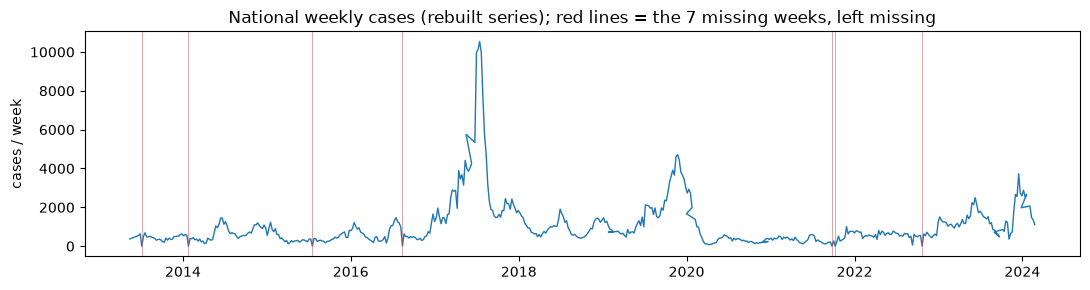

In [4]:
# The fact that shapes everything: last week explains almost all of this week.
def r2(x, y):
    m = ~(np.isnan(x) | np.isnan(y)); return np.corrcoef(x[m], y[m])[0, 1] ** 2

print(f"cases(t-1) -> cases(t): r2 = {r2(cases[:-1].ravel(), cases[1:].ravel()):.3f}   (raw counts, pooled)")
print(f"cases(t-3) -> cases(t): r2 = {r2(cases[:-3].ravel(), cases[3:].ravel()):.3f}   (the forecast horizon)")
era5 = pd.read_csv(DATA / "rebuilt_climate_weekly.csv")
wide = {ch: era5.pivot(index="week", columns="district", values=ch)[names].to_numpy()
        for ch in era5.columns if ch not in ("week", "district")}
best = max((r2(v[:-lag].ravel(), cases[lag:].ravel()), ch, lag) for ch, v in wide.items() for lag in range(2, 9))
print(f"best climate covariate, lags 2-8: r2 = {best[0]:.3f} ({best[1]}, lag {best[2]})")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(cases_df.week_start, np.nansum(cases, axis=1), lw=1)
for w in cases_df.week_start[missing]:
    ax.axvline(w, color="#C44E52", lw=0.6, alpha=0.6)
ax.set_title("National weekly cases (rebuilt series); red lines = the 7 missing weeks, left missing")
ax.set_ylabel("cases / week"); fig.tight_layout(); fig.savefig(FIGS / "nb_series.png", dpi=150); plt.show()

## 2. Why we do not use the original shifted dataset

Prior work (and the first phase of this project) used `sri_lanka_2013-2022_shifted.npy`.
It has no date axis. We dated every row against the source reports and the climate
channels against ERA5 and the authors' own raw satellite files
(`docs/ARRAY_AUDIT.md`). The measurements are loaded below.

What the audit found, in one line each:

1. **Rows are out of date order.** Rows 0–47 are 2023; the rest run 2013–2022, so
   *every* training split of the standard protocol contains data from after its test
   period — a leak of the future.
2. **Cases were reordered, climate was not.** An annual cycle fits temperature in row
   order but not against the case dates; cases and weather drift apart by ~48–55 weeks
   by 2019.
3. **The "lagged" climate channels are shifted the wrong way.** Precipitation and
   canopy "lag 12" match ERA5 best **12–13 weeks later**; min-NDVI "lag 17" best
   9–18 weeks later. A model fed them sees future weather.
4. **Weeks were lost** in processing (49 reports) and one week is duplicated.
5. **The week-395 "19× spike" is a spreadsheet error** in one published table, not an
   outbreak or a reporting backlog; the same table's cumulative row gives the true count.

So a score on the shifted array is an optimistic bound, not a forecast skill.

In [5]:
audit = json.loads((RES / "array_audit.json").read_text(encoding="utf-8"))
print("rows matching no report exactly:", audit["A_unmatched_rows"])
print("identical consecutive rows (duplicated week):", audit["A_identical_consecutive_rows"])
print("\nannual-cycle fit of each climate channel -- in row order vs against the dates the CASE rows claim:")
print(pd.DataFrame(audit["D_annual_cycle_r2"]).T.round(3).to_string())
print("\nreports in the source span / used / dropped:",
      audit["E_reports_in_source_span"], "/", audit["E_reports_used"], "/", audit["E_reports_dropped"])
print("\nthe protocol's folds on the array (training spans include the 2023 rows):")
print(json.dumps(audit["F_folds"], indent=1)[:900])

floors = pd.DataFrame(json.loads((RES / "persistence_floors.json").read_text(encoding="utf-8")))
print("\nThe persistence floor, same code and protocol, three versions of the data:")
print(floors.to_string(index=False))

rows matching no report exactly: [48, 49, 50, 54, 297, 301, 434]
identical consecutive rows (duplicated week): [[444, 445]]

annual-cycle fit of each climate channel -- in row order vs against the dates the CASE rows claim:
                     r2_row_order  r2_case_calendar
meanTair                    0.816             0.286
minTair                     0.796             0.272
meanQair                    0.530             0.108
meanSoilmoi                 0.483             0.171
meanPrecip (lag 12)         0.254             0.061
minNdvi (lag 17)            0.285             0.089

reports in the source span / used / dropped: 453 / 404 / 49

the protocol's folds on the array (training spans include the 2023 rows):
[
 {
  "origin": 0.55,
  "train_rows": [
   3,
   221
  ],
  "val_rows": [
   222,
   251
  ],
  "test_rows": [
   252,
   319
  ],
  "rows_2023_in_train": 45,
  "test_calendar": [
   "2018-03-10",
   "2019-07-13"
  ]
 },
 {
  "origin": 0.7,
  "train_rows": [
   3,
   289
  ]

## 3. Six encoders × three heads on one harness (EXP-034)

The five published ST-GNNs (Weng et al. 2024) and the LSTM of the SEIR-LSTM (Liu et al.
2025), each behind:

* **direct** — predict next weeks' cases (what the published GNNs do);
* **SEIR decoder** (`foi`) — predict a force of infection and let an SEIR simulator
  turn it into cases;
* **gated SEIR** (`foi_res`) — the simulator supplies only the *departure* from last
  week's value, through a learned gate. With a graph encoder this is our SEIR-GNN; with
  the LSTM it is the SEIR-LSTM.

Same folds, loss, early stopping and metric for all eighteen cells.

mean validation / test RMSE (3 origins x 3 seeds)
               direct   SEIR decoder     gated SEIR
AAGCN   16.76 / 35.59  23.69 / 50.06  17.44 / 35.78
ASTGCN  16.84 / 35.39  24.15 / 51.28  17.48 / 35.60
LSTM    16.91 / 35.10  24.32 / 50.25  17.69 / 35.52
STGAT   23.32 / 60.82  25.52 / 52.74  17.62 / 35.84
A3TGCN  28.63 / 60.40  25.55 / 52.92  17.68 / 35.50
DCRNN   34.89 / 73.74  25.72 / 52.28  17.67 / 35.51
persistence: 17.86 / 36.02



each SEIR head paired against the same encoder's direct head:
encoder head vs direct  val delta val wins     p  test delta test wins
  AAGCN   SEIR decoder      6.931      0/9 0.004      14.464       0/9
  AAGCN     gated SEIR      0.674      1/9 0.016       0.185       3/9
 ASTGCN   SEIR decoder      7.309      0/9 0.004      15.889       0/9
 ASTGCN     gated SEIR      0.634      2/9 0.016       0.205       3/9
   LSTM   SEIR decoder      7.410      0/9 0.004      15.158       0/9
   LSTM     gated SEIR      0.779      0/9 0.004       0.424       2/9
  STGAT   SEIR decoder      2.201      6/9 0.289      -8.082       6/9
  STGAT     gated SEIR     -5.699      9/9 0.004     -24.987       9/9
 A3TGCN   SEIR decoder     -3.085      6/9 0.035      -7.483       9/9
 A3TGCN     gated SEIR    -10.952      9/9 0.004     -24.899       9/9
  DCRNN   SEIR decoder     -9.171      9/9 0.004     -21.463       9/9
  DCRNN     gated SEIR    -17.217      9/9 0.004     -38.230       9/9


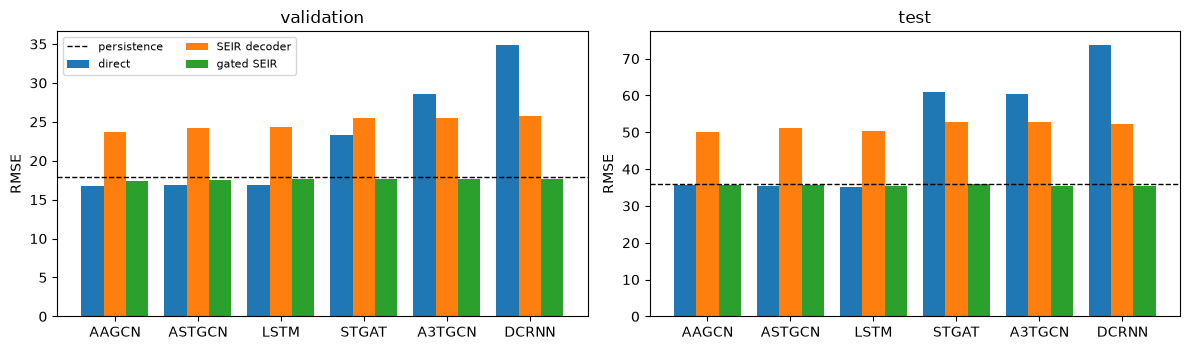

In [6]:
real = GRIDS["real"]
ENC = ["AAGCN", "ASTGCN", "LSTM", "STGAT", "A3TGCN", "DCRNN"]
HEADS = {"direct": "direct", "foi": "SEIR decoder", "foi_res": "gated SEIR"}
tab = pd.DataFrame({lab: [f"{means(real, [f'{e}+{h}'])['val'].iloc[0]:.2f} / {means(real, [f'{e}+{h}'])['test'].iloc[0]:.2f}"
                          for e in ENC] for h, lab in HEADS.items()}, index=ENC)
pv, pt = means(real, ["persistence"]).iloc[0][["val", "test"]]
print("mean validation / test RMSE (3 origins x 3 seeds)")
print(tab.to_string()); print(f"persistence: {pv:.2f} / {pt:.2f}\n")

rows = []
for e in ENC:
    for h in ("foi", "foi_res"):
        v, t = compare(real, f"{e}+{h}", f"{e}+direct"), compare(real, f"{e}+{h}", f"{e}+direct", "RMSE")
        rows.append({"encoder": e, "head vs direct": HEADS[h], "val delta": v["delta"], "val wins": v["wins"],
                     "p": v["p"], "test delta": t["delta"], "test wins": t["wins"]})
print("each SEIR head paired against the same encoder's direct head:")
print(pd.DataFrame(rows).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
x = np.arange(len(ENC))
for ax, metric, title in ((axes[0], "val_RMSE", "validation"), (axes[1], "RMSE", "test")):
    for k, (h, lab) in enumerate(HEADS.items()):
        ax.bar(x + (k - 1) * 0.27, [real.loc[real.name == f"{e}+{h}", metric].mean() for e in ENC], 0.27, label=lab)
    ax.axhline(real.loc[real.name == "persistence", metric].mean(), color="k", ls="--", lw=1, label="persistence")
    ax.set_xticks(x, ENC); ax.set_title(title); ax.set_ylabel("RMSE")
axes[0].legend(fontsize=8, ncol=2); fig.tight_layout(); fig.savefig(FIGS / "nb_encoders.png", dpi=150); plt.show()

**Reading it.**

* **Architecture matters little.** Behind the direct head the three working encoders
  (AAGCN, ASTGCN, LSTM) sit within 0.15 of each other, and the LSTM has no graph at all.
  STGAT, A3TGCN and DCRNN are worse than persistence as published.
* **The SEIR decoder is worse than persistence on every encoder**, and 6.9–7.4 worse
  than the direct head on each working encoder (on the failing ones it beats their
  broken direct head, but is still far behind persistence).
* **The gated SEIR head brings all six to 17.44–17.69**, below persistence on
  validation and test, repairing the three failing encoders on 9/9 runs each. It looks
  like the physics result the study set out to find. Section 5 tests whether it is.

## 4. Why the pure SEIR decoder fails (EXP-032)

This is a no-training diagnosis (`seirgnn2/diagnose_foi.py`, needs the repository and
torch): invert the simulator by bisection for the force of infection λ that reproduces
each observed count exactly, then ask what a network would need to predict.

| measurement | value | meaning |
|---|---|---|
| targets below the λ = 0 floor | **14–16%** | exposed individuals already seeded from recent cases emit more cases than observed even with transmission switched off; unreachable at any network output |
| cells needing λ pinned at 0 | 39% | |
| r² of log λ* from case history | **0.22–0.26** | against 0.81–0.82 for the direct target: the network must predict a far noisier quantity |
| 10× training budget | −0.04 | not an optimisation problem (EXP-033) |
| cells hitting the susceptible clamp | 2.5% | not susceptible depletion |

The r² ≈ 0.25 result independently replicates, on the corrected data and through a
different mechanism, the earlier renewal-equation finding on the old array: the
reproduction number is about 26% predictable out of sample.

Re-run it with `RERUN = True` and `"diagnose_foi"` in `RERUN_GRIDS` (section 14).

## 5. Anchor, gate or physics? The rescue control (EXP-048)

The gated SEIR head differs from the direct head in three ways at once: it forecasts a
**departure from last week's value** (the anchor), it shrinks that departure through a
**learned gate**, and the departure comes from the **SEIR simulator**. Only the third
is physics. The pre-registered control (`docs/RESCUE_PLAN.md`) reruns all six encoders
behind four heads that add these one at a time:

`direct` → `residual` (anchor) → `gated` (anchor + gate; our no-physics twin) →
`gated SEIR` (anchor + gate + simulator).

**Decision rule, fixed before the run:** the rescue is credited to physics only if
gated SEIR beats `gated` with ≥ 7/9 wins and BH-adjusted p < 0.05 on each failing
encoder.

In [7]:
res = GRIDS["rescue"]
H4 = ["direct", "residual", "gated", "foi_res"]
print("mean validation RMSE (all rerun together on Kaggle):")
print(pd.DataFrame({h: [res.loc[res.name == f"{e}+{h}", "val_RMSE"].mean() for e in ENC] for h in H4},
                   index=ENC).round(2).to_string())
print(f"persistence: {res.loc[res.name == 'persistence', 'val_RMSE'].mean():.2f}\n")

prim = pd.DataFrame([{"encoder": e, **compare(res, f"{e}+foi_res", f"{e}+gated"),
                      "test delta": compare(res, f"{e}+foi_res", f"{e}+gated", "RMSE")["delta"],
                      "test wins": compare(res, f"{e}+foi_res", f"{e}+gated", "RMSE")["wins"]} for e in ENC])
prim.loc[prim.encoder.isin(["STGAT", "A3TGCN", "DCRNN"]), "p_adj"] = bh(prim.p[prim.encoder.isin(["STGAT", "A3TGCN", "DCRNN"])])
print("PRIMARY: gated SEIR minus its no-physics twin (negative favours physics); BH over the 3 failing encoders")
print(prim.round(4).to_string(index=False))

share = []
for e in ["STGAT", "A3TGCN", "DCRNN"]:
    d, g, f = (res.loc[res.name == f"{e}+{h}", "val_RMSE"].mean() for h in ("direct", "gated", "foi_res"))
    share.append({"encoder": e, "repair by SEIR head": d - f, "repair by anchor+gate alone": d - g, "share": (d - g) / (d - f)})
print("\nshare of the validation repair carried by anchor + gate, (direct - gated) / (direct - gated SEIR):")
print(pd.DataFrame(share).round(3).to_string(index=False))

mean validation RMSE (all rerun together on Kaggle):
        direct  residual  gated  foi_res
AAGCN   16.760    16.750 16.580   17.460
ASTGCN  16.830    16.780 16.740   17.480
LSTM    16.910    16.950 16.940   17.690
STGAT   23.320    17.840 16.950   17.620
A3TGCN  28.630    17.470 17.680   17.680
DCRNN   34.780    17.490 18.360   17.680
persistence: 17.86



PRIMARY: gated SEIR minus its no-physics twin (negative favours physics); BH over the 3 failing encoders
encoder  delta wins     p  test delta test wins  p_adj
  AAGCN  0.881  0/9 0.004       2.027       0/9    NaN
 ASTGCN  0.738  0/9 0.004       0.954       3/9    NaN
   LSTM  0.744  0/9 0.004      -0.339       6/9    NaN
  STGAT  0.673  2/9 0.016      -0.827       7/9  0.047
 A3TGCN -0.003  6/9 0.984      -1.653       9/9  0.984
  DCRNN -0.685  3/9 0.250      -3.333       9/9  0.375

share of the validation repair carried by anchor + gate, (direct - gated) / (direct - gated SEIR):
encoder  repair by SEIR head  repair by anchor+gate alone  share
  STGAT                5.693                        6.366  1.118
 A3TGCN               10.952                       10.949  1.000
  DCRNN               17.105                       16.421  0.960


**Verdict: the rescue is the anchor, not the physics.** Anchor and gate alone carry
96–112% of the repair; a plain residual head already brings the failing encoders to
17.47–17.84. The simulator is significantly *worse* than its twin on STGAT, ties on
A3TGCN, helps DCRNN on only 3/9 runs, and costs the working encoders 0.74–0.88 on 0/9.
On **test** the simulator does beat its twin on the failing encoders — the recurring
validation/test disagreement of section 11, reported and not claimed.

## 6. Every lever we tried, paired against its own control

Each row pairs an arm with the control *from its own grid* on the nine matched
`(origin, seed)` runs. BH is applied across the whole table (more conservative than the
per-experiment families of the log, which remain the record of each adoption decision).
An arm was **adopted** only if validation delta < 0, wins ≥ 7/9, and horizon-3 error did
not rise.

             group                                     lever         grid  val delta wins     p  p_adj  test delta  consistent gain
            worked          NB likelihood (vs squared error)        combo     -0.415  9/9 0.004  0.018       1.574             True
            worked                         seasonal features       screen     -0.810  6/9 0.109  0.204       1.072            False
            worked               best model B vs persistence        combo     -2.197  9/9 0.004  0.018       1.537             True
graph/architecture         graph (GCN vs no message passing)       screen     -0.070  4/9 0.379  0.516      -0.199            False
graph/architecture                         learned adjacency       screen     -0.140  5/9 0.109  0.204      -0.259            False
graph/architecture                  district seasonal curves         arch     -0.015  6/9 0.895  0.945       0.485            False
graph/architecture                      nonlinear (MLP) head         arch   

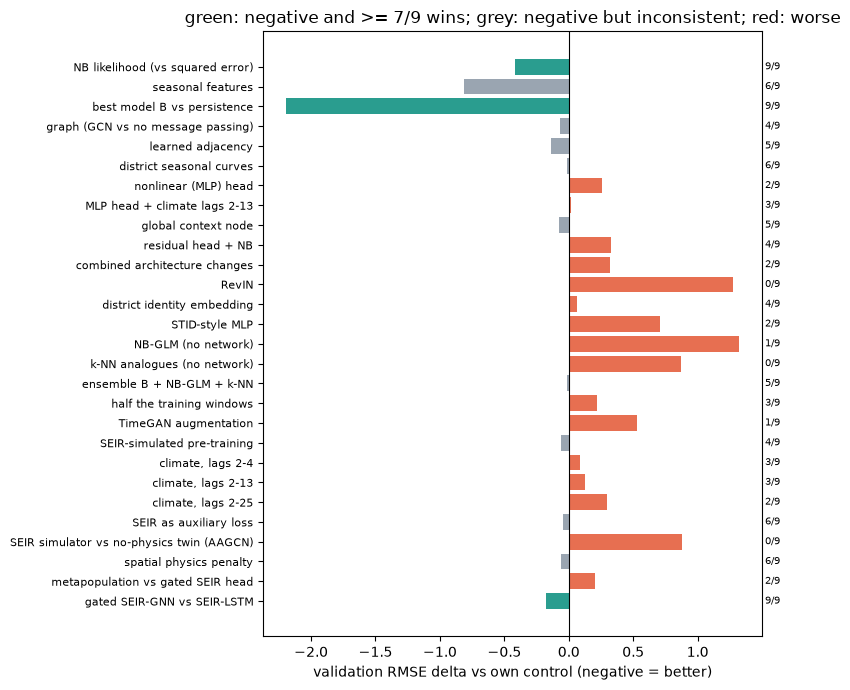

In [8]:
LEVERS = json.loads((RES / "levers.json").read_text(encoding="utf-8"))
lev = []
for group, label, grid, arm, ref in LEVERS:
    df = GRIDS[grid]; v = compare(df, arm, ref); t = compare(df, arm, ref, "RMSE")
    w = int(v["wins"].split("/")[0])
    lev.append({"group": group, "lever": label, "grid": grid, "val delta": v["delta"], "wins": v["wins"], "p": v["p"],
                "test delta": t["delta"], "consistent gain": v["delta"] < 0 and w >= 7})
lev = pd.DataFrame(lev); lev.insert(6, "p_adj", bh(lev.p))
print(lev.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(lev))[::-1]
ax.barh(y, lev["val delta"], color=np.where(lev["consistent gain"], "#2a9d8f", np.where(lev["val delta"] < 0, "#9aa5b1", "#e76f51")))
ax.axvline(0, color="k", lw=0.8); ax.set_yticks(y, lev.lever, fontsize=8)
ax.set_xlabel("validation RMSE delta vs own control (negative = better)")
for yy, w in zip(y, lev.wins):
    ax.text(ax.get_xlim()[1], yy, f" {w}", va="center", fontsize=7)
ax.set_title("green: negative and >= 7/9 wins; grey: negative but inconsistent; red: worse")
fig.tight_layout(); fig.savefig(FIGS / "nb_levers.png", dpi=150); plt.show()

## 7. The best model against persistence — validation and test

`B` = AAGCN + direct head + negative-binomial likelihood + seasonal features, the
best configuration on validation.

In [9]:
combo = GRIDS["combo"]
print("three origins (combo grid):")
print(means(combo, ["AAGCN+direct season nb", "LSTM+direct season nb", "ASTGCN+foi_res season nb",
                    "LSTM+foi_res season nb", "persistence"]).round(2).to_string())
for metric in ("val_RMSE", "RMSE"):
    r = compare(combo, "AAGCN+direct season nb", "persistence", metric)
    print(f"  B vs persistence, {metric:8s}: {r['delta']:+.2f}  wins {r['wins']}  p {r['p']:.4f}")

print("\nnine disjoint origins, origin unit (the unit a claim about the series rests on):")
for grid, arm in (("confirm", "AAGCN+direct"), ("physics9", "P0 B")):
    for metric in ("val_RMSE", "RMSE"):
        r = compare(GRIDS[grid], arm, "persistence", metric, "origin")
        print(f"  {grid:8s} {arm:13s} vs persistence, {metric:8s}: {r['delta']:+.2f}  wins {r['wins']}  p {r['p']:.3f}")

three origins (combo grid):
                            val   test  runs
name                                        
AAGCN+direct season nb   15.660 37.550     9
LSTM+direct season nb    15.800 35.700     9
ASTGCN+foi_res season nb 16.650 35.260     9
LSTM+foi_res season nb   17.270 34.970     9
persistence              17.860 36.020     3
  B vs persistence, val_RMSE: -2.20  wins 9/9  p 0.0039
  B vs persistence, RMSE    : +1.54  wins 3/9  p 0.2070

nine disjoint origins, origin unit (the unit a claim about the series rests on):
  confirm  AAGCN+direct  vs persistence, val_RMSE: -2.89  wins 8/9  p 0.035
  confirm  AAGCN+direct  vs persistence, RMSE    : +2.17  wins 4/9  p 0.324
  physics9 P0 B          vs persistence, val_RMSE: -2.92  wins 8/9  p 0.035
  physics9 P0 B          vs persistence, RMSE    : +1.45  wins 4/9  p 0.367


**Reading it.** On validation, B beats persistence consistently (−2.20, 9/9 on three
origins; −2.9, 8/9 on nine). On **test it does not** — it is *worse* than persistence
on both origin sets. The NB likelihood, the largest controlled validation gain in the
study (−0.41, 9/9), is also worse on test (section 6). This is the first sign of the
validation/test disagreement analysed in section 11.

## 8. SEIR-GNN against SEIR-LSTM — the research question

Same gated SEIR head, graph encoder vs Liu et al.'s LSTM.

      comparison (graph minus LSTM)        unit  val delta val wins  val p  test delta test wins  test p
       3 origins, ASTGCN, NB+season origin_seed     -0.623      9/9  0.004       0.298       6/9   0.430
        3 origins, AAGCN, NB+season origin_seed     -0.176      9/9  0.004      -0.155       5/9   0.254
    3 origins, AAGCN (physics grid) origin_seed     -0.174      9/9  0.004      -0.044       5/9   0.664
   3 origins, DIRECT head (no SEIR) origin_seed     -0.140      5/9  0.289       1.858       1/9   0.012
        9 origins, ASTGCN (EXP-038)      origin     -0.752      8/9  0.012       0.228       4/9   0.410
         9 origins, AAGCN (EXP-047)      origin     -0.006      6/9  0.996      -0.412       6/9   0.031
9 origins, metapopulation (EXP-047)      origin      0.512      4/9  0.344      -0.007       4/9   0.988


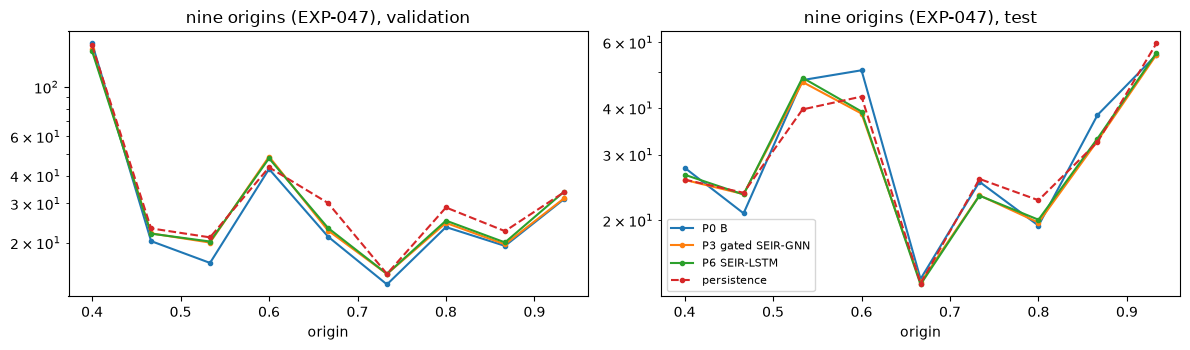

In [10]:
rows = []
for label, grid, arm, ref, unit in [
    ("3 origins, ASTGCN, NB+season", "combo", "ASTGCN+foi_res season nb", "LSTM+foi_res season nb", "origin_seed"),
    ("3 origins, AAGCN, NB+season", "combo", "AAGCN+foi_res season nb", "LSTM+foi_res season nb", "origin_seed"),
    ("3 origins, AAGCN (physics grid)", "physics", "P3 gated SEIR-GNN", "P6 SEIR-LSTM", "origin_seed"),
    ("3 origins, DIRECT head (no SEIR)", "combo", "AAGCN+direct season nb", "LSTM+direct season nb", "origin_seed"),
    ("9 origins, ASTGCN (EXP-038)", "confirm", "ASTGCN+foi_res", "LSTM+foi_res", "origin"),
    ("9 origins, AAGCN (EXP-047)", "physics9", "P3 gated SEIR-GNN", "P6 SEIR-LSTM", "origin"),
    ("9 origins, metapopulation (EXP-047)", "physics9", "P4 metapopulation SEIR-GNN", "P6 SEIR-LSTM", "origin"),
]:
    v, t = compare(GRIDS[grid], arm, ref, "val_RMSE", unit), compare(GRIDS[grid], arm, ref, "RMSE", unit)
    rows.append({"comparison (graph minus LSTM)": label, "unit": unit, "val delta": v["delta"], "val wins": v["wins"],
                 "val p": v["p"], "test delta": t["delta"], "test wins": t["wins"], "test p": t["p"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

p9 = GRIDS["physics9"]; origins9 = sorted(p9.origin.unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, metric, title in ((axes[0], "val_RMSE", "validation"), (axes[1], "RMSE", "test")):
    for arm in ("P0 B", "P3 gated SEIR-GNN", "P6 SEIR-LSTM", "persistence"):
        ax.plot(origins9, [p9[(p9.name == arm) & (p9.origin == o)][metric].mean() for o in origins9],
                marker="o", ms=3, ls="--" if arm == "persistence" else "-", label=arm)
    ax.set_yscale("log"); ax.set_title(f"nine origins (EXP-047), {title}"); ax.set_xlabel("origin")
axes[1].legend(fontsize=8); fig.tight_layout(); fig.savefig(FIGS / "nb_nine.png", dpi=150); plt.show()

**Reading it.** On three origins the graph wins on validation every time (9/9), and
only inside the SEIR head — behind the direct head it gains nothing. On nine origins
that does not hold up: the ASTGCN run wins on validation but **loses on test**; the
AAGCN run ties on validation and wins on test. Neither clears its corrected threshold,
and the two confirmations named different endpoints (a flaw in our pre-registration).
**We do not claim that SEIR-GNN beats SEIR-LSTM.** Origin 0.40's validation span holds
the 2017 epidemic and dominates every validation mean on the nine-origin grids; read
the win counts.

## 9. Physics as structure: spatial penalty and metapopulation coupling (EXP-046)

In [11]:
ph = GRIDS["physics"]
print(means(ph).round(2).to_string()); print()
for arm, ref in (("P1 spatial penalty (ratio)", "P0 B"), ("P2 spatial penalty (log)", "P0 B"),
                 ("P4 metapopulation SEIR-GNN", "P3 gated SEIR-GNN"), ("P5 metapop + spatial + district season", "P3 gated SEIR-GNN")):
    r = compare(ph, arm, ref); print(f"{arm:40s} vs {ref:18s} {r['delta']:+.3f}  {r['wins']}  p {r['p']:.4f}")
h3 = ph.groupby("name")["RMSE_h3"].mean()
print(f"\n(test horizon-3 RMSE, recorded only: P1 {h3['P1 spatial penalty (ratio)']:.2f} vs P0 {h3['P0 B']:.2f})")

                                          val   test  runs
name                                                      
P1 spatial penalty (ratio)             15.590 38.050     9
P0 B                                   15.650 37.550     9
P2 spatial penalty (log)               15.660 37.730     9
P3 gated SEIR-GNN                      17.100 34.920     9
P5 metapop + spatial + district season 17.190 35.340     9
P6 SEIR-LSTM                           17.280 34.970     9
P4 metapopulation SEIR-GNN             17.310 35.120     9
persistence                            17.860 36.020     3

P1 spatial penalty (ratio)               vs P0 B               -0.059  6/9  p 0.3828
P2 spatial penalty (log)                 vs P0 B               +0.018  6/9  p 0.6992
P4 metapopulation SEIR-GNN               vs P3 gated SEIR-GNN  +0.203  2/9  p 0.0156
P5 metapop + spatial + district season   vs P3 gated SEIR-GNN  +0.083  2/9  p 0.1328

(test horizon-3 RMSE, recorded only: P1 42.27 vs P0 41.67)


**Reading it.** The spatial penalty — the one significant physics gain on the old array
(−0.044 on STGAT, 57/60 runs) — keeps its sign on the best model but wins only 6/9 and
is not adopted. Coupling districts inside the SEIR dynamics (a MepoGNN-style
metapopulation head) is *worse* than the gated head. On the old array, Moran's I of
log R on the district graph was 0.005: transmission has almost no local spatial
structure at district-week resolution, so a learned coupling has nothing to encode.

## 10. The informational ceiling (EXP-039)

Every model family we trained makes nearly the same errors. The forecast-level
diagnosis (`seirgnn2/diagnose_arch.py`, which needs the per-run forecasts that are too
large for the package) is reproduced below from its committed output.

In [12]:
txt = (RES / "diagnose_arch.txt").read_text(encoding="utf-8")
best_cfg = txt[txt.index("# config = best"):]   # the configuration the paper uses (NB + season)
for block in ("1. RMSE by horizon", "2. Does the forecast", "3. Mean error", "6. Correlation of residuals",
              "8. Residual left on the table"):
    i = best_cfg.index(block); j = best_cfg.find("\n\n", i)
    print(best_cfg[i:j if j > 0 else None].rstrip(), "\n")

1. RMSE by horizon, and skill = 1 - RMSE/persistence (positive is better)
   arm             all      h1      h2      h3   skill h1     h2     h3
   persistence   18.39   15.72   18.05   21.03
   STGAT         20.34   19.57   20.21   21.22    -0.245  -0.120  -0.009
   A3TGCN        27.85   27.03   27.79   28.71    -0.719  -0.540  -0.365
   ASTGCN        16.23   14.22   16.10   18.12    +0.096  +0.108  +0.138
   AAGCN         15.85   14.04   15.65   17.65    +0.107  +0.133  +0.161
   LSTM          16.16   14.10   15.94   18.18    +0.103  +0.117  +0.135
   SEIR-LSTM     17.69   14.78   17.39   20.45    +0.060  +0.036  +0.028 

2. Does the forecast move with the truth?  Regress predicted log-growth on
   realised log-growth: slope 0 = persistence, 1 = tracks change fully.
   arm           slope       r      r2    sd(pred growth)/sd(true)
   STGAT         0.468   0.409   0.167                       1.144
   A3TGCN        0.427   0.323   0.104                       1.324
   ASTGCN        0.

**Reading it.** Residuals of the working encoders correlate 0.98–0.99 with each other
(0.87–0.99 across every family including k-NN, which has no network); a linear model on
the same inputs recovers only 4–6% of their residual variance. The remaining error is a
lag on moves — under-predicting rises and over-predicting falls — concentrated in the
top 5% of district-weeks. Add more data, synthetic data, climate or architecture, and
the errors stay the same (section 6).

## 11. Validation and test disagree, systematically

In every grid we can ask: does the arm validation ranks first also rank well on test?

In [13]:
out = []
for g, df in GRIDS.items():
    if g == "window":   # arms with different window lengths are scored on different test windows
        continue
    m = means(df).drop(index=[n for n in means(df).index if n.startswith("persistence")])
    pers = df.loc[df.name == "persistence", "RMSE"].mean()
    best_val = m.val.idxmin(); best_test = m.test.idxmin()
    out.append({"grid": g, "arms": len(m), "rank corr(val, test)": m.val.rank().corr(m.test.rank()),
                "picked by validation": best_val, "its test": m.loc[best_val, "test"],
                "best on test": best_test, "best test": m.loc[best_test, "test"], "persistence test": pers})
print(pd.DataFrame(out).round(2).to_string(index=False))
anchored = re.compile(r"foi_res|residual|gated|knn|SEIR|P3|P4|P5|P6|ENS\[B \+ R4b")
vt = pd.DataFrame(out)
print(f"\nGrids where the arm validation picks is WORSE than persistence on test: "
      f"{int((vt['its test'] > vt['persistence test']).sum())} of {len(vt)}")
print(f"Grids where the best arm on test is anchored to last week (gated SEIR, residual, gated, k-NN): "
      f"{sum(bool(anchored.search(r['best on test'])) for r in out)} of {len(out)}")

        grid  arms  rank corr(val, test)         picked by validation  its test            best on test  best test  persistence test
      screen    15                 0.080                  feat=season    35.420              loss=smape     33.960            36.020
        real    18                 0.820                 AAGCN+direct    35.590             LSTM+direct     35.100            36.020
       combo    24                -0.470       AAGCN+direct season nb    37.550    AAGCN+foi_res all nb     34.540            36.020
     confirm     5                 0.700               ASTGCN+foi_res    31.700            LSTM+foi_res     31.470            31.760
remedies+ens    13                -0.040              R6 aux_phys 0.1    37.170        ENS[B + R4b knn]     34.180            36.020
       curve     4                 0.200                  B frac=0.75    37.630             B frac=0.25     36.870            36.020
     augment     9                 0.200 G3d seir pretrain calibrated

**Reading it.** In most grids the arm that validation picks is worse than persistence
on test, while the best arm on test is usually one anchored to last week's value (gated
SEIR, residual, gated, k-NN), and the validation/test rank correlation is often
negative. Nothing here was selected on
test, so none of those test wins is a result. But the pattern suggests that a 30-week
validation span immediately before each origin rewards fitting that span's level, which
does not carry into the next period. Settling it needs a new pre-registered protocol and
data nothing here has touched — the weekly reports after March 2024.

## 12. What happened to the earlier "positive physics" results (EXP-049)

Before the leakage-controlled re-run, three results were reported as physics wins.
The outputs of the Kaggle kernels that produced them were recovered and are analysed
here.

In [14]:
# (a) EXP-027: "STGAT SEIR-GNN test RMSE 26.10 on origin 0.70, outperforming persistence 36.016".
s5 = pd.DataFrame(json.loads((RES / "s5_seir_gnn_results_kaggle_0914.json").read_text(encoding="utf-8")))
s5["arch"] = s5.arch.str.strip()
pers = pd.DataFrame(json.loads((RES / "corrected_persistence.json").read_text(encoding="utf-8")))
pers = pers[pers.dataset == "rebuilt"].set_index("origin")["RMSE"]
stg = s5[(s5.arch == "STGAT") & (s5.head_type == "foi")].groupby("origin")["test_RMSE"].mean()
print("(a) the S5 SEIR-GNN against persistence at MATCHED origins (same fold builder):")
print(pd.DataFrame({"STGAT + SEIR head (test)": stg, "persistence (test)": pers}).round(2).to_string())
print(f"    pooled: {stg.mean():.2f} vs {pers.mean():.2f}. The 26.10 quoted one origin against persistence pooled over three.")
print("    Our recomputed persistence at 0.70 from the raw series (section 1):",
      round(check.query("grid == 'real' and origin == 0.7")["recomputed test"].iloc[0], 2))

# (b) The last full run of that pipeline (Kaggle, 2026-09-15): its own gates.
log = (RES / "full_workflow_summary.txt").read_text(encoding="utf-8")
print("\n(b) the pipeline's own last run, key lines:")
print("\n".join(dict.fromkeys(l for l in log.splitlines()
                              if re.search(r"Gate G5|Beats Baseline|S\* vs|Early-Warning", l))))

# (c) The legacy-array "physics super-ensemble" (spatial penalty in every arm), never logged.
se = pd.concat([pd.DataFrame(json.loads((RES / f).read_text(encoding="utf-8"))).assign(head=h)
                for f, h in (("beat_phys_super_spatial.json", "det"), ("beat_phys_super_gauss_spatial.json", "gauss"))])
floor = se[se.arm == "floor"].groupby("origin")["RMSE_clean"].mean()
arms = se[se.arm != "floor"].groupby(["head", "arch", "arm", "origin"])["RMSE_clean"].mean().reset_index()
arms["d"] = arms.RMSE_clean - arms.origin.map(floor)
g = arms.groupby(["head", "arch", "arm"])["d"]
summ = pd.DataFrame({"delta vs floor": g.mean(), "wins": g.apply(lambda d: f"{int((d < 0).sum())}/{len(d)}"),
                     "p": g.apply(lambda d: sign_flip_p(d.to_numpy()))})
summ["p_adj (all arms)"] = bh(summ.p)
print(f"\n(c) legacy-array super-ensemble: {len(summ)} arm x head comparisons against the per-origin floor; best five:")
print(summ.sort_values("delta vs floor").head(5).round(3).to_string())

(a) the S5 SEIR-GNN against persistence at MATCHED origins (same fold builder):
        STGAT + SEIR head (test)  persistence (test)
origin                                              
0.550                     84.770              38.950
0.700                     26.420              22.400
0.850                     72.170              46.690
    pooled: 61.12 vs 36.02. The 26.10 quoted one origin against persistence pooled over three.


    Our recomputed persistence at 0.70 from the raw series (section 1): 22.4

(b) the pipeline's own last run, key lines:
[Gate G5] Finalist S*: STGAT (input=cases, coupling=explicit, head=direct) with Val RMSE=25.823, Test RMSE=69.040
Executing Stage S7 Early-Warning Outbreak Detection Evaluation...
=== Stage S7: Early-Warning Evaluation ===
       S* vs B* (ASTGCN base)         0.50              0.83333                False
            S* vs Persistence         0.50              0.83333                False
         S* vs Direct Control         1.00              1.00000                False
              S* vs SEIR-LSTM         0.75              0.93750                False
Early-Warning AUC of S* vs B*         0.04              0.20000                False
Beats Baseline Claim Satisfied? False (Wins on origins: 1/9, BH p-adj=0.8333)



(c) legacy-array super-ensemble: 128 arm x head comparisons against the per-origin floor; best five:
                                           delta vs floor wins     p  p_adj (all arms)
head  arch                arm                                                         
det   AAGCN+ASTGCN+A3TGCN multi_raw                -0.848  7/9 0.059             0.288
gauss AAGCN+ASTGCN+A3TGCN multi_raw                -0.724  6/9 0.109             0.424
det   AAGCN+ASTGCN+A3TGCN multi_opt_raw            -0.654  7/9 0.059             0.288
      ASTGCN              ens_raw                  -0.653  7/9 0.078             0.333
gauss AAGCN+ASTGCN+A3TGCN multi_blend_raw          -0.643  6/9 0.113             0.426


**Verdict.** None of the earlier physics wins survives:

* **(a)** At the same origin, persistence scored **22.40** against the SEIR-GNN's
  26.4 — it lost at every origin. The quoted win compared one origin with persistence
  averaged over three. That pipeline also had four training defects (one gradient step
  per epoch, a SMAPE objective scored by RMSE, a force of infection held constant
  across the horizon, and every covariate collapsed to a scalar before the graph).
* **(b)** Its own last full run chose a *direct* head on validation and reported
  "Beats Baseline Claim Satisfied? False".
* **(c)** The legacy-array ensemble's best arm is 0.85 below the floor on 7/9 origins
  (exact sign-flip p = 0.06 here; the kernel's own test printed 0.09). Across its 128
  comparisons nothing survives correction (best p_adj 0.29). Its third stage crashed on a
  bug and never ran.

Two earlier results still stand, **on the old array only**: the spatial penalty's
−0.044 on STGAT (57/60 runs) and the outbreak-ranking AUC gain 0.807 → 0.826. On the
corrected data the penalty is −0.06, 6/9 (section 9).

## 13. Summary of findings

In [15]:
L = lev.set_index("lever")
summary = pd.DataFrame([
    ("data", "benchmark array leaks the future (row order, future-shifted climate lags)", "section 2", "confirmed"),
    ("data", "persistence floor reproduces exactly from the raw corrected series", "section 1", "confirmed"),
    ("architecture", f"working encoders within 0.15; graph adds {L.loc['graph (GCN vs no message passing)', 'val delta']:+.2f}", "sections 3, 6", "negative"),
    ("physics", "pure SEIR decoder worse than persistence on every encoder", "sections 3-4", "negative, explained"),
    ("physics", "gated SEIR head repairs 3 failing encoders", "section 3", "true, but..."),
    ("physics", "...the repair is the persistence anchor, not the simulator", "section 5", "confirmed (pre-registered)"),
    ("physics", "spatial penalty / metapopulation coupling", "section 9", "not adopted"),
    ("training", f"NB likelihood {L.loc['NB likelihood (vs squared error)', 'val delta']:+.2f} on validation, 9/9", "section 6", "positive on val; worse on test"),
    ("headline", "best model beats persistence on validation, not on test", "section 7", "mixed"),
    ("research question", "SEIR-GNN vs SEIR-LSTM: 9/9 on 3 origins, not robust on 9", "section 8", "not established"),
    ("ceiling", "all families make the same errors (residual corr 0.87-0.99)", "section 10", "confirmed"),
    ("protocol", "validation selects models that underperform anchored ones on test", "section 11", "open; needs post-2024 data"),
    ("history", "earlier positive physics results", "section 12", "withdrawn"),
], columns=["area", "finding", "where", "status"])
print(summary.to_string(index=False))

             area                                                                   finding         where                         status
             data benchmark array leaks the future (row order, future-shifted climate lags)     section 2                      confirmed
             data        persistence floor reproduces exactly from the raw corrected series     section 1                      confirmed
     architecture                            working encoders within 0.15; graph adds -0.07 sections 3, 6                       negative
          physics                 pure SEIR decoder worse than persistence on every encoder  sections 3-4            negative, explained
          physics                                gated SEIR head repairs 3 failing encoders     section 3                   true, but...
          physics                ...the repair is the persistence anchor, not the simulator     section 5     confirmed (pre-registered)
          physics                        

## 14. Re-running any of it

Set `RERUN = True` in the first code cell and list grids in `RERUN_GRIDS`, then run the
notebook **from inside the repository** (`full_paper/` next to `seirgnn2/`). The cell
below retrains each listed grid with the frozen protocol and the analysis above then
uses the fresh rows. Approximate CPU cost with 6 workers:

| grid | what | time |
|---|---|---|
| `screen` | heads, losses, graph modes, features (toy GCN) | ~3 min |
| `real` | six encoders × three heads | ~70 min (DCRNN dominates) |
| `combo` | encoders × features × likelihood × head | ~40 min |
| `confirm`, `physics9` | the nine-origin confirmations | ~70 min each |
| `remedies`, `augment`, `climate`, `arch`, `physics`, `curve` | the lever grids | 10-40 min each |
| `rescue` | the anchor/gate/physics control | ~2 h (DCRNN) |
| `diagnose_foi` | the SEIR-decoder diagnosis (no training) | seconds |

Real encoders need `pip install torch-geometric` and
`pip install --no-deps torch-geometric-temporal`. Each grid can instead be run on Kaggle
with `python scripts/build_seirgnn2_kernel.py --grid <grid> --keep` (see
`seirgnn2/README.md`); Kaggle and local runs agree on means but not run-for-run, so never
pair arms across environments.

In [16]:
EPOCHS = {"screen": 300, "real": 300, "rescue": 300}
if RERUN:
    assert REPO is not None, "RERUN needs the repository: open this notebook from full_paper/ inside the repo"
    for g in RERUN_GRIDS:
        if g == "diagnose_foi":
            cmd = [sys.executable, str(REPO / "seirgnn2" / "diagnose_foi.py")]
        else:
            cmd = [sys.executable, str(REPO / "seirgnn2" / "sweep.py"), "remedies" if g == "remedies+ens" else g,
                   "--workers", "6", "--epochs", str(EPOCHS.get(g, 400))]
        print("$", " ".join(cmd), flush=True)
        subprocess.run(cmd, cwd=REPO, check=True)
    print("done -- re-run the notebook from the top to analyse the fresh rows")
else:
    print("RERUN is False: every number above comes from the committed per-run rows in outputs/results.")

RERUN is False: every number above comes from the committed per-run rows in outputs/results.
